## Trial-level verifier metrics

Per-trial decoder accuracy + dataset-scale stats pulled from `harbor-jobs/<ds>/<agent>/<trial>/verifier/metrics.json`. The pull script is `eval/pull_trial_metrics.py`; loaders live in `utils.py` (`load_trial_metrics`, `trial_metrics_df`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle as _Rect

%load_ext autoreload
%autoreload 2

import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from utils import load_trial_metrics, trial_metrics_df

mdf = trial_metrics_df(load_trial_metrics())

# Display-name mirror of analysis.ipynb's cell 9fc5189e
DISPLAY_NAME = {"allen2p": "Allen2P", "zhang2025": "Zhang2025 (IBL)"}
def display_name(ds):
    return DISPLAY_NAME.get(ds, ds[:1].upper() + ds[1:])

SUPERVISED_DS   = ["allen2p", "lee2025", "majnik2025", "sosa2024"]
UNSUPERVISED_DS = ["chen2024", "hasnain2024", "zhang2025", "zhong2025"]

### Per-dataset metric table (figure)

Two figures (supervised / unsupervised). Layout mirrors the rating-square summary from `analysis.ipynb`: rows = metric, columns = dataset, each cell is a 6-square strip (3 claude-code + 3 codex). Supervised cells are coloured by ratio (RdYlGn centred at 1.0); unsupervised cells are flat grey raw values. Decoder section breaks out one row per decoded variable; variables differ per dataset, so shorter columns leave bottom slots empty.

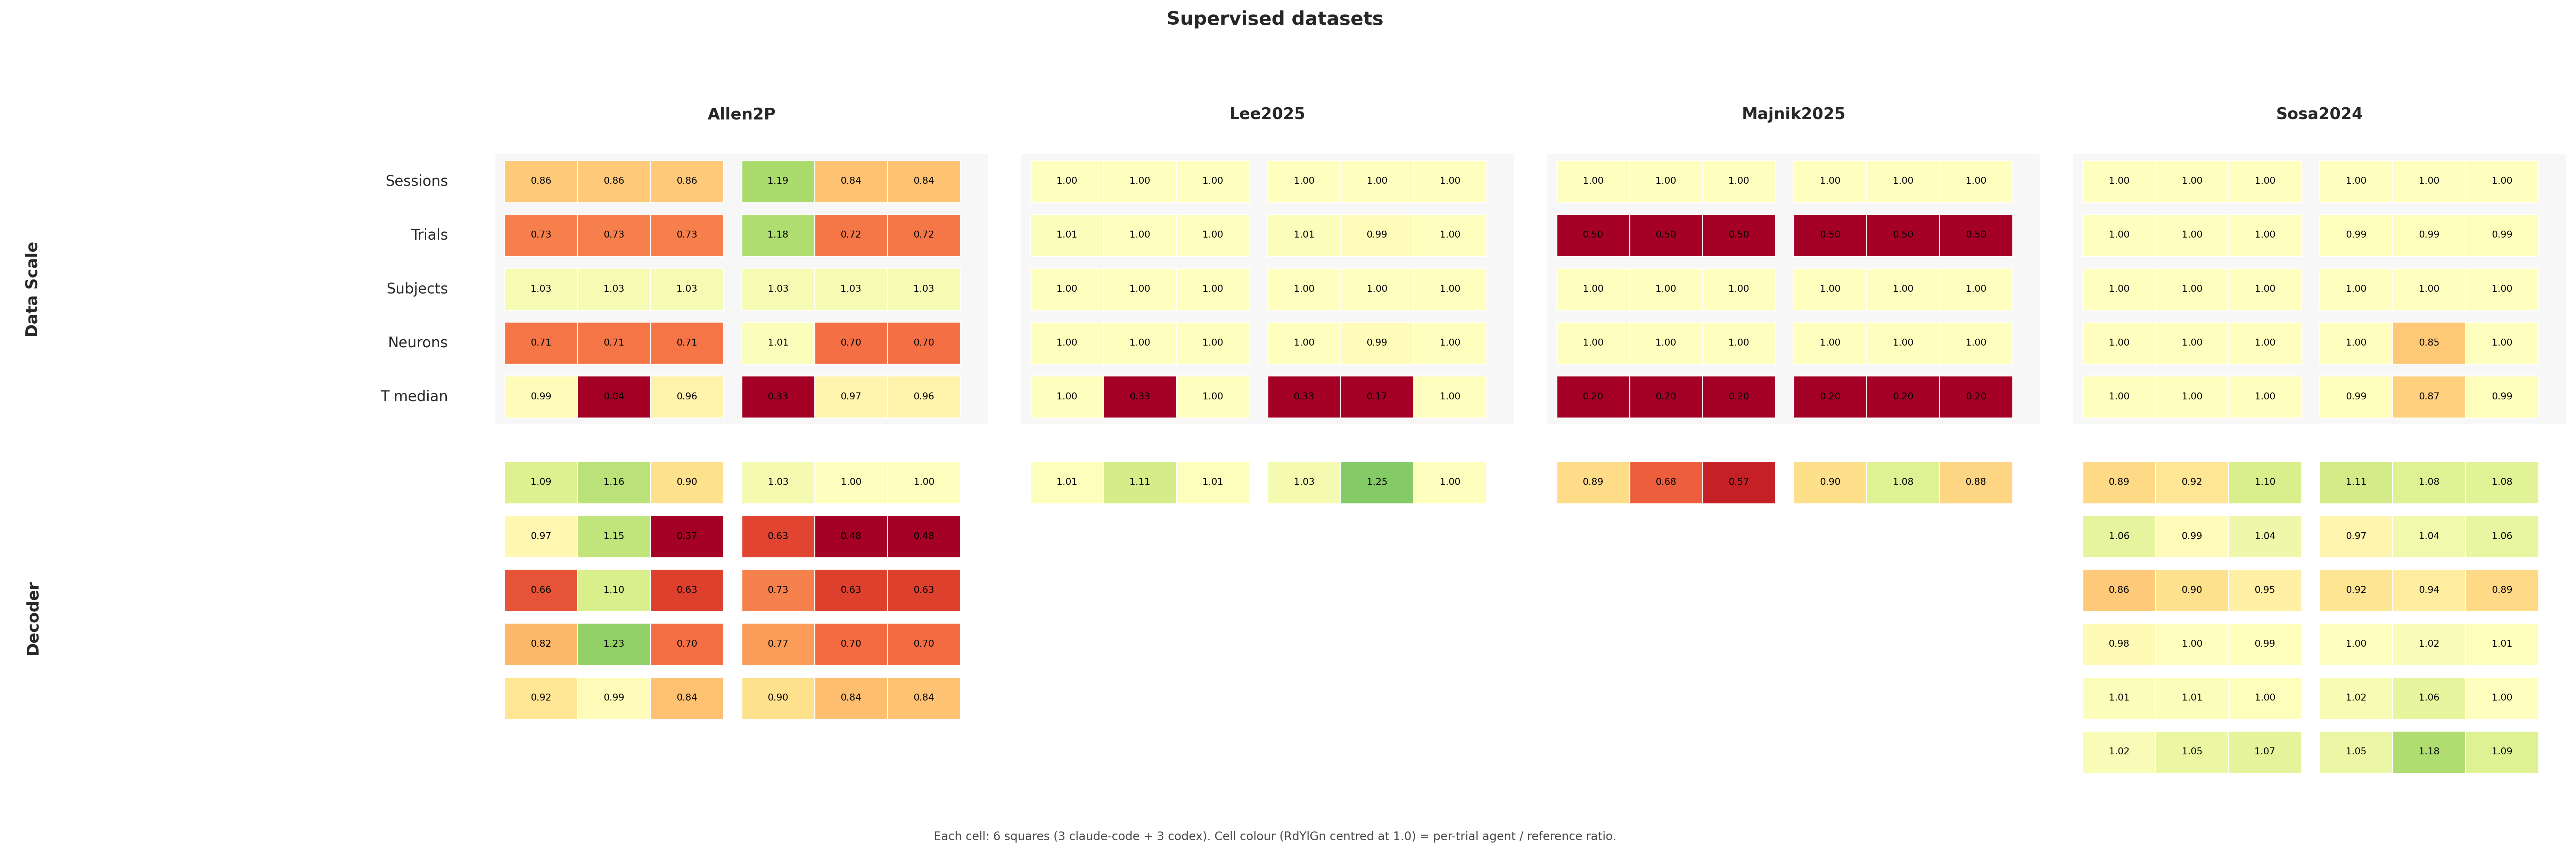

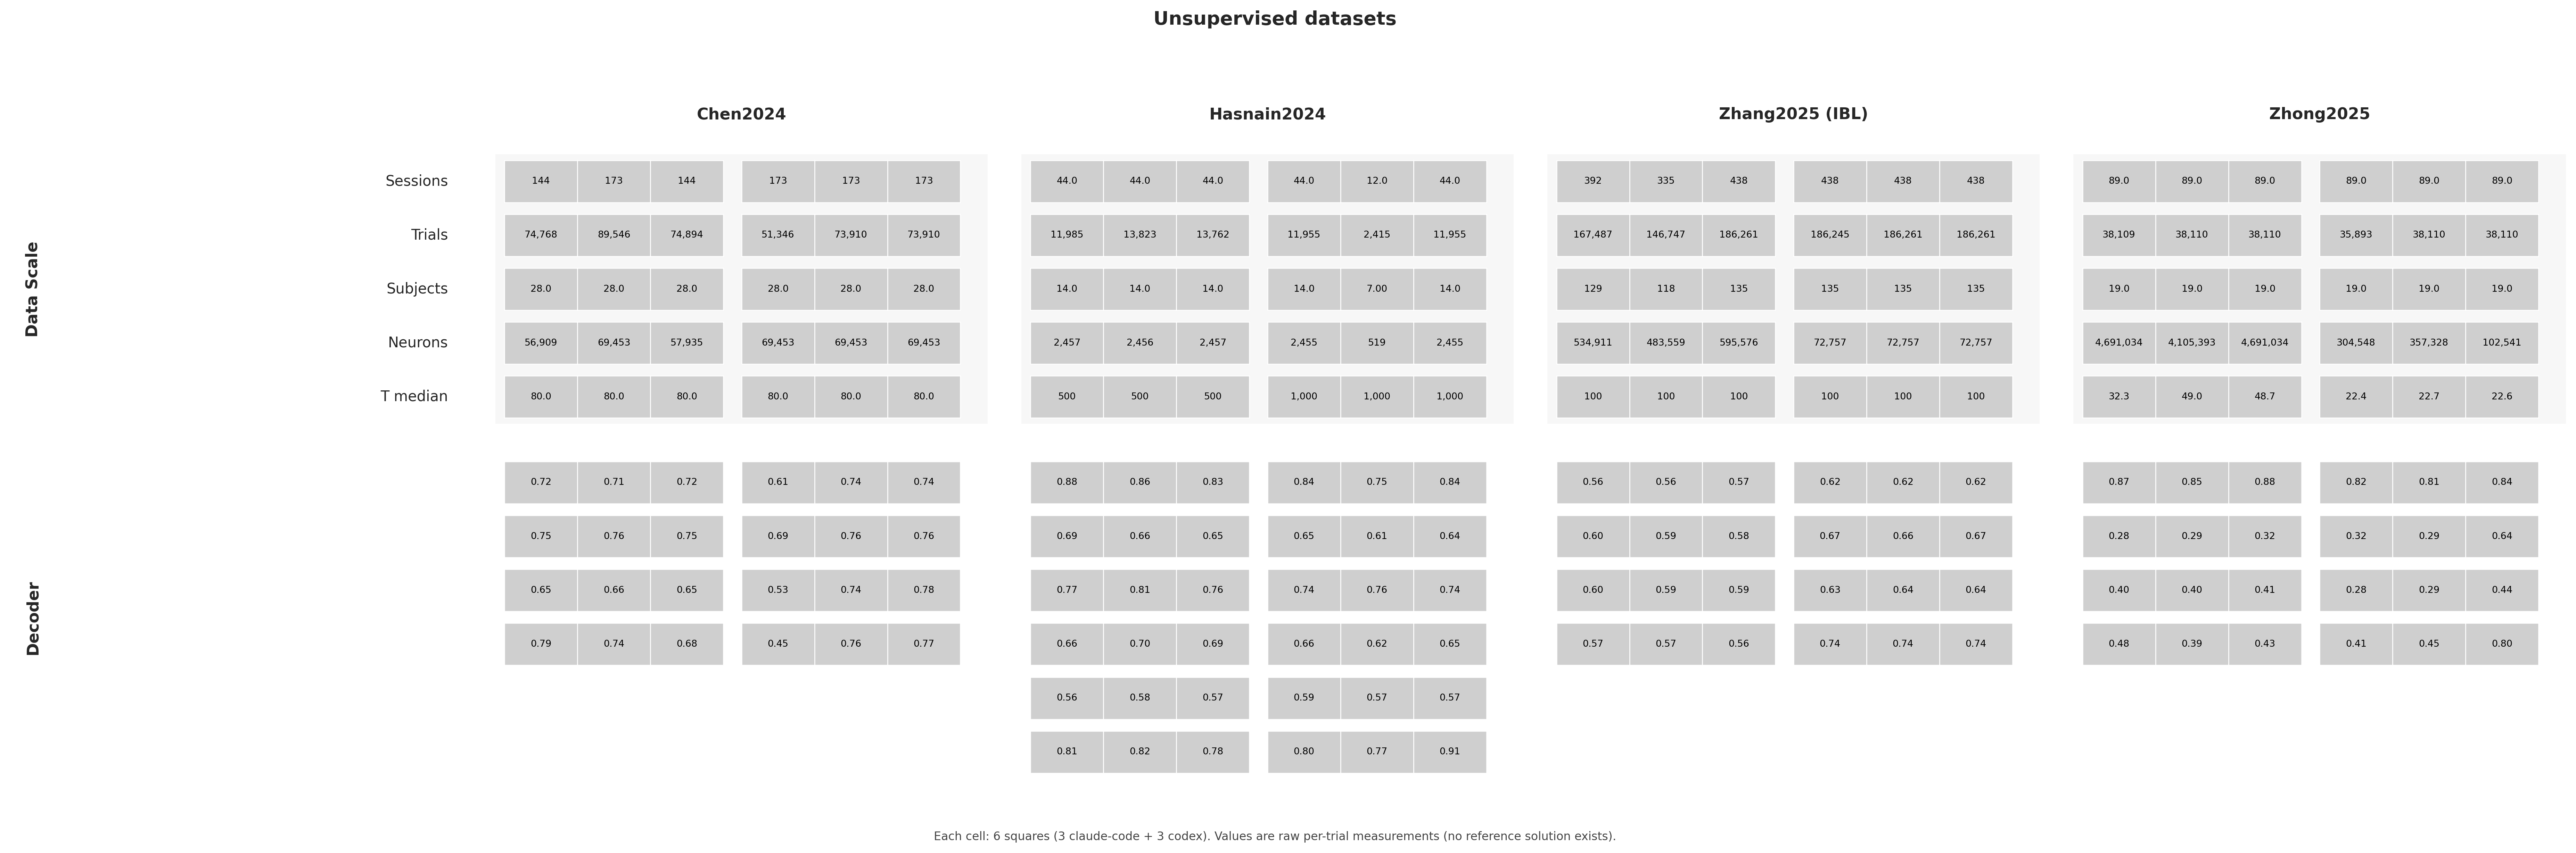

In [2]:
SCALE_FIELDS = [
    ("Sessions",  "nsessions"),
    ("Trials",    "ntrials_total"),
    ("Subjects",  "nsubjects"),
    ("Neurons",   "nneurons_total"),
    ("T median",  "T_median"),
]


def _trial_values(ds, ratio_col, raw_col):
    """6-array of per-trial values + is_ratio flag (claude×3 then codex×3)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    if ratio_col and ratio_col in sub.columns and not sub[ratio_col].isna().all():
        return sub[ratio_col].values.astype(float), True
    if raw_col and raw_col in sub.columns and not sub[raw_col].isna().all():
        return sub[raw_col].values.astype(float), False
    return np.full(6, np.nan), False


def _decoder_var_rows(ds, supervised):
    """[(var_name, values, is_ratio), ...] for one dataset's decoder vars."""
    sub = mdf[mdf.dataset == ds]
    if supervised:
        prefix     = "validation_balanced_accuracy_ratio."
        raw_prefix = "validation_balanced_accuracy."
    else:
        prefix     = "validation_balanced_accuracy."
        raw_prefix = None
    cols = sorted(c for c in sub.columns
                  if c.startswith(prefix) and not sub[c].isna().all())
    out = []
    for c in cols:
        var = c[len(prefix):]
        ratio_col = c if supervised else None
        raw_col   = f"{raw_prefix}{var}" if raw_prefix else c
        vals, is_r = _trial_values(ds, ratio_col, raw_col)
        out.append((var, vals, is_r))
    return out


def _build_rows(datasets, supervised):
    rows_per_ds = {}
    for ds in datasets:
        rs = []
        for label, key in SCALE_FIELDS:
            ratio_col = f"{key}_ratio" if supervised else None
            vals, is_r = _trial_values(ds, ratio_col, key)
            rs.append(("Data Scale", label, vals, is_r))
        for var, vals, is_r in _decoder_var_rows(ds, supervised):
            rs.append(("Decoder", var, vals, is_r))
        rows_per_ds[ds] = rs
    return rows_per_ds


_cmap     = plt.get_cmap("RdYlGn")
_cnorm    = mcolors.TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
NAN_GREY  = "#f2f2f2"
RAW_GREY  = "#cfcfcf"


def _fmt(v, is_ratio):
    if np.isnan(v):
        return ""
    if is_ratio:
        return f"{v:.2f}"
    if v >= 1000: return f"{v:,.0f}"
    if v >= 100:  return f"{v:.0f}"
    if v >= 10:   return f"{v:.1f}"
    return f"{v:.2f}"


def render_metric_table(datasets, *, supervised, footnote, suptitle=None):
    """Build the metric-summary figure for one dataset family."""
    rows_per_ds    = _build_rows(datasets, supervised=supervised)
    n_scale_rows   = len(SCALE_FIELDS)
    n_decoder_rows = max(sum(1 for r in rows if r[0] == "Decoder")
                         for rows in rows_per_ds.values())
    n_cols = len(datasets)

    square         = 0.85
    n_squares      = 6
    agent_gap      = 0.20
    cell_inner_pad = 0.05
    sq_w           = (square * 6 - agent_gap - 2 * cell_inner_pad) / n_squares
    sq_h           = square * 0.78
    section_gap    = 0.5
    title_pad      = 1.4

    y_top       = 0.0
    y_scale_top = y_top
    y_scale_bot = y_scale_top - n_scale_rows * square
    y_dec_top   = y_scale_bot - section_gap
    y_dec_bot   = y_dec_top - n_decoder_rows * square
    data_y_range = (y_top - y_dec_bot) + title_pad + 0.4
    data_x_range = square * 6 + 0.30

    left, right, top, bottom, wspace = 0.02, 0.99, 0.92, 0.05, 0.05
    label_w_ratio     = 0.9
    cell_aspect_fudge = 1.45

    fig_h_in = 0.55 * (n_scale_rows + n_decoder_rows + 2) + 1.0
    axes_h_in = fig_h_in * (top - bottom)
    data_axes_w = axes_h_in / (data_y_range / data_x_range) * cell_aspect_fudge
    total_axes_w = (label_w_ratio + n_cols) * data_axes_w * (1 + wspace)
    fig_w_in = total_axes_w / (right - left)

    fig, axes = plt.subplots(
        1, n_cols + 1, figsize=(fig_w_in, fig_h_in), sharey=True,
        gridspec_kw={"width_ratios": [label_w_ratio] + [1.0] * n_cols},
    )
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom, wspace=wspace)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=0.985)

    def _row_y(section, idx):
        if section == "Data Scale":
            return y_scale_top - idx * square
        return y_dec_top - idx * square

    def _draw_cell(ax, x_left, y_top_cell, vals, is_ratio):
        sq_y = y_top_cell - (square - sq_h) / 2 - sq_h
        x = x_left + cell_inner_pad
        for k, v in enumerate(vals):
            if k == 3:
                x += agent_gap
            if np.isnan(v):
                face, txt_color = NAN_GREY, "#888"
            elif is_ratio:
                face, txt_color = mcolors.to_hex(_cmap(_cnorm(v))), "black"
            else:
                face, txt_color = RAW_GREY, "black"
            ax.add_patch(_Rect((x, sq_y), sq_w, sq_h,
                               facecolor=face, edgecolor="white",
                               linewidth=0.6, zorder=1))
            text = _fmt(v, is_ratio)
            if text:
                ax.text(x + sq_w / 2, sq_y + sq_h / 2, text,
                        ha="center", va="center",
                        fontsize=6.5, color=txt_color, zorder=2)
            x += sq_w

    # --- Label axes ---
    ax_lbl = axes[0]
    ax_lbl.set_xlim(0, 1)
    ax_lbl.set_ylim(y_dec_bot - 0.4, y_top + title_pad)
    ax_lbl.set_axis_off()
    for sec_label, y_hi, y_lo in [
        ("Data Scale", y_scale_top, y_scale_bot),
        ("Decoder",    y_dec_top,   y_dec_bot),
    ]:
        ax_lbl.text(0.05, (y_hi + y_lo) / 2, sec_label,
                    ha="center", va="center", fontsize=11,
                    fontweight="bold", rotation=90)
    for i, (label, _) in enumerate(SCALE_FIELDS):
        y_mid = _row_y("Data Scale", i) - square / 2
        ax_lbl.text(0.97, y_mid, label, ha="right", va="center", fontsize=10)

    # --- Per-dataset axes ---
    for j, ds in enumerate(datasets):
        ax = axes[j + 1]
        ax.add_patch(_Rect((0, y_scale_bot),
                           data_x_range, y_scale_top - y_scale_bot,
                           facecolor="#f7f7f7", edgecolor="none", zorder=-1))
        scale_idx = decoder_idx = 0
        for section, label, vals, is_ratio in rows_per_ds[ds]:
            if section == "Data Scale":
                y_top_cell = _row_y("Data Scale", scale_idx)
                scale_idx += 1
            else:
                y_top_cell = _row_y("Decoder", decoder_idx)
                decoder_idx += 1
            _draw_cell(ax, 0.05, y_top_cell, vals, is_ratio)
        ax.set_xlim(-0.1, data_x_range)
        ax.set_ylim(y_dec_bot - 0.4, y_top + title_pad)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.text(data_x_range / 2, y_top + 0.5, display_name(ds),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

    fig.text(0.5, 0.005, footnote,
             ha="center", va="bottom", fontsize=8, color="#444")
    plt.show()


render_metric_table(
    SUPERVISED_DS, supervised=True,
    suptitle="Supervised datasets",
    footnote="Each cell: 6 squares (3 claude-code + 3 codex). Cell colour "
             "(RdYlGn centred at 1.0) = per-trial agent / reference ratio.",
)

render_metric_table(
    UNSUPERVISED_DS, supervised=False,
    suptitle="Unsupervised datasets",
    footnote="Each cell: 6 squares (3 claude-code + 3 codex). Values are "
             "raw per-trial measurements (no reference solution exists).",
)

### Decoder accuracy LaTeX tables

Two tables (supervised + unsupervised) showing the per-trial decoder values. Rows = (Dataset, Variable). Columns = the 3 claude-code trials and the 3 codex trials. Numbers match exactly what's plotted above; the table makes them easier to read off and copy into the paper. For supervised datasets the values are agent/reference ratios; for unsupervised they're raw validation balanced accuracy.

In [3]:
# LaTeX tables — one per dataset family. Reuses _decoder_var_rows from
# the plotting cell above so naming / ordering / alias normalisation is
# identical between the figure and the table. The supervised table also
# shows a Reference column with the manual-solution absolute balanced
# accuracy followed by the chance level (1/n_classes) in parens, and
# colours the per-trial ratios by deviation from 1.0:
#   ratio > 1.10           → blue
#   0.90 <= ratio <= 1.10  → black (default)
#   0.70 <= ratio <  0.90  → orange
#   ratio <  0.70          → red

# Per-(dataset, variable) chance level, extracted from the "Accuracy vs
# Chance" tables that the agents wrote into
# `harbor-jobs/<ds>/<agent>/<trial>/verifier/snapshot/CONVERSION_NOTES.md`.
# Where multiple trials reported different values for the same variable
# (because agents picked different binnings) we use the modal value across
# the 9-ish reporting trials. See `harbor-jobs/.../CONVERSION_NOTES.md`
# under the "Check 1: Accuracy vs Chance" section for the originals.
# Variable names here are the *ratio* (canonical) names — for sosa2024
# `position` is the same conceptual variable as `absolute_position` in the
# notes, and `reward_location` is `reward_zone_location`.
CHANCE_LEVELS = {
    # Supervised
    "allen2p": {
        "image_change":   0.500,    # binary
        "image_name":     0.0625,   # 1/16 — modal across agents (some used 1/8 or 1/17)
        "pupil_diameter": 0.200,    # 5-class
        "running_speed":  0.200,    # 5-class
        "trial_outcome":  0.250,    # 4-class
    },
    "lee2025":    {"position":      0.1111},  # 1/9
    "majnik2025": {"motion_energy": 0.200},   # 5-class
    "sosa2024": {
        "position":                0.200,     # = absolute_position in notes
        "speed":                   0.200,
        "lick":                    0.500,
        "distance_to_reward_zone": 0.1429,    # 1/7
        "reward_location":         0.3333,    # = reward_zone_location in notes
        "reward_outcome":          0.500,
    },
    # Unsupervised — same source. Keys are the canonical (alias-applied)
    # variable names that show up as rows in the unsupervised table.
    "chen2024": {
        "choice":     0.500,    # binary
        "early_lick": 0.500,    # binary
        "outcome":    0.3333,   # 1/3
        "tongue_y":   0.3333,   # 1/3 (was tongue_y_position in notes)
    },
    "hasnain2024": {
        "context":         0.500,   # binary (was behavioral_context in notes)
        "lick_direction":  0.500,   # binary
        "motion_energy":   0.500,   # binary
        "outcome":         0.500,   # binary
        "paw_velocity":    0.500,   # binary
        "tongue_velocity": 0.500,   # binary
    },
    "zhang2025": {
        "choice":                0.500,   # binary
        "prior":                 0.3333,  # 1/3 (was prior_probability_left/_of_left in notes)
        "wheel_speed":           0.3333,
        "whisker_motion_energy": 0.3333,
    },
    "zhong2025": {
        "licking":         0.500,   # binary
        "position":        0.250,   # 4-class (modal — one agent used 5-class)
        "running_speed":   0.250,   # 4-class
        "visual_stimulus": 0.0667,  # 1/15 — modal; some agents used 4-class or binary
    },
}

# Per-dataset row order overrides for the supervised table. Variables not
# listed here keep the alphabetical default from _decoder_var_rows.
ROW_ORDER = {
    "allen2p":  ["trial_outcome", "running_speed", "pupil_diameter",
                 "image_name", "image_change"],
    "sosa2024": ["position", "speed", "lick", "distance_to_reward_zone",
                 "reward_location", "reward_outcome"],
    # Unsupervised orderings.
    "chen2024":    ["choice", "outcome", "early_lick", "tongue_y"],
    "hasnain2024": ["context", "outcome", "lick_direction",
                    "tongue_velocity", "paw_velocity", "motion_energy"],
    "zhang2025":   ["prior", "choice", "wheel_speed", "whisker_motion_energy"],
    # zhong2025: alphabetical default (licking, position, running_speed, visual_stimulus)
}


def _ordered_decoder_rows(ds, supervised):
    """`_decoder_var_rows` reordered per ROW_ORDER if listed."""
    rows = _decoder_var_rows(ds, supervised)
    desired = ROW_ORDER.get(ds)
    if not desired:
        return rows
    by_var = {r[0]: r for r in rows}
    out = [by_var[v] for v in desired if v in by_var]
    out += [r for r in rows if r[0] not in set(desired)]
    return out


def _ratio_color(v):
    if np.isnan(v):
        return None
    if v > 1.10: return "blue"
    if v < 0.70: return "red"
    if v < 0.90: return "orange"
    return None


def _fmt_ratio(v):
    if np.isnan(v):
        return "--"
    s = f"{v:.3f}"
    color = _ratio_color(v)
    return r"\textcolor{" + color + r"}{" + s + r"}" if color else s


def _ref_value(ds, var):
    """Reference (manual-solution) absolute balanced accuracy for this var."""
    col = f"validation_balanced_accuracy_reference.{var}"
    sub = mdf[mdf.dataset == ds]
    if col not in sub.columns or sub[col].isna().all():
        return float("nan")
    return float(sub[col].dropna().iloc[0])


def _fmt_chance(c):
    """Chance level rendered to 3 decimal places."""
    return f"{c:.3f}"


def _latex_supervised_table(datasets, *, label, caption):
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr c}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} & Reference \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (chance) \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        rows = _ordered_decoder_rows(ds, supervised=True)
        if not rows:
            continue
        n = len(rows)
        for ri, (var, vals, _is_ratio) in enumerate(rows):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            var_cell = var.replace("_", r"\_")
            ratio_cells = [_fmt_ratio(v) for v in vals]
            ref = _ref_value(ds, var)
            chance = CHANCE_LEVELS.get(ds, {}).get(var)
            if np.isnan(ref):
                ref_cell = "--"
            elif chance is None:
                ref_cell = f"{ref:.3f}"
            else:
                ref_cell = f"{ref:.3f} ({_fmt_chance(chance)})"
            lines.append(" & ".join([ds_cell, var_cell, *ratio_cells, ref_cell])
                         + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


def _latex_unsupervised_table(datasets, *, label, caption):
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr c}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} & Average \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (chance) \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        rows = _ordered_decoder_rows(ds, supervised=False)
        if not rows:
            continue
        n = len(rows)
        for ri, (var, vals, _is_ratio) in enumerate(rows):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            var_cell = var.replace("_", r"\_")
            row_mean = float(np.nanmean(vals)) if not np.all(np.isnan(vals)) else np.nan
            # Ratio = each trial / row mean — same colour scheme as supervised.
            ratio_cells = [_fmt_ratio(np.nan if np.isnan(v) or np.isnan(row_mean) or row_mean == 0
                                      else v / row_mean) for v in vals]
            chance = CHANCE_LEVELS.get(ds, {}).get(var)
            if np.isnan(row_mean):
                ref_cell = "--"
            elif chance is None:
                ref_cell = f"{row_mean:.3f}"
            else:
                ref_cell = f"{row_mean:.3f} ({_fmt_chance(chance)})"
            lines.append(" & ".join([ds_cell, var_cell, *ratio_cells, ref_cell])
                         + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


print(_latex_supervised_table(
    SUPERVISED_DS,
    label="tab:decoder-supervised",
    caption=("Per-trial decoder performance, supervised datasets. The "
             "first six numeric columns are the agent / reference ratio "
             "of validation balanced accuracy (T1--T3 of each agent). "
             "Colour: \\textcolor{blue}{blue} if ratio $>$ 1.10, "
             "\\textcolor{orange}{orange} if 0.70 $\\leq$ ratio $<$ 0.90, "
             "\\textcolor{red}{red} if ratio $<$ 0.70. The Reference column "
             "shows the manual-solution absolute balanced accuracy with the "
             "chance level $1/n_{classes}$ in parentheses."),
))

print()
print(_latex_unsupervised_table(
    UNSUPERVISED_DS,
    label="tab:decoder-unsupervised",
    caption=("Per-trial decoder performance, unsupervised datasets. "
             "No reference solution exists, so each row's mean across the "
             "6 trial runs is used in lieu of a reference and the per-"
             "trial values shown are ratios relative to that row mean "
             "(colour scheme matches Table~\\ref{tab:decoder-supervised}: "
             "\\textcolor{blue}{blue} if ratio $>$ 1.10, "
             "\\textcolor{orange}{orange} if 0.70 $\\leq$ ratio $<$ 0.90, "
             "\\textcolor{red}{red} if ratio $<$ 0.70). The Average "
             "column shows the row mean (absolute balanced accuracy) "
             "with the chance level $1/n_{classes}$ in parentheses."),
))


% requires \usepackage{booktabs, multirow, xcolor}
\begin{table}[t]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code} & \multicolumn{3}{c}{Codex} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (chance) \\
\midrule
\multirow{5}{*}{Allen2P} & trial\_outcome & 0.919 & 0.991 & \textcolor{orange}{0.838} & 0.905 & \textcolor{orange}{0.836} & \textcolor{orange}{0.840} & 0.319 (0.250) \\
 & running\_speed & \textcolor{orange}{0.820} & \textcolor{blue}{1.230} & \textcolor{orange}{0.703} & \textcolor{orange}{0.774} & \textcolor{red}{0.699} & \textcolor{red}{0.698} & 0.350 (0.200) \\
 & pupil\_diameter & \textcolor{red}{0.659} & \textcolor{blue}{1.101} & \textcolor{red}{0.628} & \textcolor{orange}{0.734} & \textcolor{red}{0.629} & \textcolor{red}{0.628} & 0.432 (0.200) \\
 & image\_name & 0.974 & \textcolor{blue}{1.146} & \textcolor{red}{0.372} & \textcolor{red}{0.634} & \tex

### Data Scale LaTeX tables

Same layout as the decoder-accuracy tables but for the dataset-scale metrics (Sessions, Trials, Subjects, Neurons, T median). Supervised: agent / reference ratios. Unsupervised: per-trial values as ratios to the row mean (no reference exists), with the row mean in the Average column.

In [4]:
# LaTeX tables — Data Scale (Sessions / Trials / Subjects / Neurons /
# T_median). Same layout and colour scheme as the decoder accuracy tables —
# one table per dataset family, (dataset × metric) per row.
#   * Supervised: each cell is the per-trial agent / reference ratio of the
#     scale metric. The Reference column shows the absolute reference value
#     where it can be derived (raw / ratio); for datasets that store only
#     ratios in the verifier output, the cell is "--".
#   * Unsupervised: no reference exists, so the per-trial cells are the
#     ratio of each trial's raw value to the row mean (matches the
#     unsupervised decoder table). The Average column shows the row mean.

SCALE_FIELDS_LATEX = [
    ("Sessions", "nsessions"),
    ("Trials",   "ntrials_total"),
    ("Subjects", "nsubjects"),
    ("Neurons",  "nneurons_total"),
    ("T median", "T_median"),
]

# Reference (manual-solution) scale stats per supervised dataset.
# Sources:
#   lee2025 / majnik2025 / sosa2024 — from harbor-jobs/<ds>/oracle/.../verifier/
#                                     snapshot/stats_full.json (data_summary
#                                     block; nneurons_total = sum of
#                                     brain_region_neuron_counts).
#   allen2p — no oracle folder; derived from raw / ratio in any agent trial.
REFERENCE_SCALE = {
    "allen2p":    {"nsessions": 236, "ntrials_total": 71242, "nsubjects": 37,
                   "nneurons_total": 41390, "T_median": 265.2},
    "lee2025":    {"nsessions": 207, "ntrials_total":  8187, "nsubjects":  7,
                   "nneurons_total": 69744, "T_median": 1800.0},
    "majnik2025": {"nsessions":  41, "ntrials_total":  1090, "nsubjects":  6,
                   "nneurons_total": 20445, "T_median": 1800.0},
    "sosa2024":   {"nsessions": 152, "ntrials_total": 12216, "nsubjects": 11,
                   "nneurons_total": 138678, "T_median": 197.5},
}


def _fmt_scale_abs(v, key):
    """Format an absolute scale value. T median: 1dp. Other counts: comma
    format. Exception: nneurons_total uses compact K notation when >= 100K
    (e.g. 305K, 2375K). No M-suffix — even millions are kept in K so the
    reader doesn't have to mentally switch units across rows."""
    if v is None or np.isnan(v):
        return "--"
    if key == "T_median":
        return f"{v:.1f}"
    if key == "nneurons_total" and v >= 100_000:
        return f"{v / 1_000:,.0f}K"
    return f"{v:,.0f}"


def _scale_supervised_row(ds, key):
    """(ratios_6, reference_value) for one (dataset, metric)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    ratio_col = f"{key}_ratio"
    if ratio_col not in sub.columns or sub[ratio_col].isna().all():
        return np.full(6, np.nan), float("nan")
    ratios = sub[ratio_col].values.astype(float)
    ref = REFERENCE_SCALE.get(ds, {}).get(key, float("nan"))
    return ratios, ref


def _scale_unsupervised_row(ds, key):
    """(per-trial raw/mean ratios, row mean) for one (dataset, metric)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    if key not in sub.columns or sub[key].isna().all():
        return np.full(6, np.nan), float("nan")
    raws = sub[key].values.astype(float)
    mean = float(np.nanmean(raws))
    if mean == 0 or np.isnan(mean):
        return np.full(6, np.nan), mean
    return raws / mean, mean


def _latex_scale_table(datasets, *, supervised, label, caption):
    last_col = "Reference" if supervised else "Average"
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr c}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} & " + last_col + r" \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 & \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        n = len(SCALE_FIELDS_LATEX)
        for ri, (mlabel, key) in enumerate(SCALE_FIELDS_LATEX):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            if supervised:
                ratios, ref = _scale_supervised_row(ds, key)
            else:
                ratios, ref = _scale_unsupervised_row(ds, key)
            ratio_cells = [_fmt_ratio(v) for v in ratios]
            ref_cell = _fmt_scale_abs(ref, key)
            lines.append(" & ".join([ds_cell, mlabel, *ratio_cells, ref_cell])
                         + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


print(_latex_scale_table(
    SUPERVISED_DS, supervised=True,
    label="tab:scale-supervised",
    caption=("Dataset-scale statistics, supervised datasets. Each cell "
             "is the agent / reference ratio of the scale metric (T1--T3 of "
             "each agent). Colour key matches "
             "Table~\\ref{tab:decoder-supervised}: \\textcolor{blue}{blue} "
             "if ratio $>$ 1.10, \\textcolor{orange}{orange} if 0.70 "
             "$\\leq$ ratio $<$ 0.90, \\textcolor{red}{red} if ratio $<$ "
             "0.70. The Reference column shows the absolute manual-solution "
             "value."),
))

print()
print(_latex_scale_table(
    UNSUPERVISED_DS, supervised=False,
    label="tab:scale-unsupervised",
    caption=("Dataset-scale statistics, unsupervised datasets. No reference "
             "exists, so each row's mean across the 6 trial runs is used in "
             "lieu of a reference and the per-trial values shown are ratios "
             "relative to that row mean (colour scheme matches "
             "Table~\\ref{tab:decoder-supervised}). The Average column "
             "shows the row mean (absolute value)."),
))


% requires \usepackage{booktabs, multirow, xcolor}
\begin{table}[t]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code} & \multicolumn{3}{c}{Codex} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 & \\
\midrule
\multirow{5}{*}{Allen2P} & Sessions & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{blue}{1.191} & \textcolor{orange}{0.843} & \textcolor{orange}{0.843} & 236 \\
 & Trials & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{blue}{1.183} & \textcolor{orange}{0.717} & \textcolor{orange}{0.717} & 71,242 \\
 & Subjects & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 37 \\
 & Neurons & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & 1.012 & \textcolor{orange}{0.705} & \textcolor{orange}{0.705} & 41,390 \\
 & T median & 0.990 & \textcolor{red